# Spaceship Titanic

## Задача

_Необходимо создать модель, способную предсказать: достигнет пассажир другое измерений._

## Импорт библиотек и файлов

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df_test_target = pd.read_csv("../data/sample_submission.csv")
df_train = pd.read_csv("../data/train.csv")
df_test = pd.read_csv("../data/test.csv")

In [5]:
df_test_target.head()

,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,False
3,0021_01,False
4,0023_01,False


In [6]:
df_train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [8]:
df_test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [9]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   object 
 1   HomePlanet    4190 non-null   object 
 2   CryoSleep     4184 non-null   object 
 3   Cabin         4177 non-null   object 
 4   Destination   4185 non-null   object 
 5   Age           4186 non-null   float64
 6   VIP           4184 non-null   object 
 7   RoomService   4195 non-null   float64
 8   FoodCourt     4171 non-null   float64
 9   ShoppingMall  4179 non-null   float64
 10  Spa           4176 non-null   float64
 11  VRDeck        4197 non-null   float64
 12  Name          4183 non-null   object 
dtypes: float64(6), object(7)
memory usage: 434.5+ KB


## Обозначения

1. `PassengerId` - уникальный **идентификатор** каждого пассажира.
2. `HomePlanet` - **планета**, с которой выехал пассажир.
3. `CryoSleep` - **идентификатор** выбора креосна пассажира во время поездки.
4. `Cabin` - **номер каюты** пассажира.
5. `Destination` - **планета назначения**, на которую отправляется человек.
6. `Age` - **возраст** пассажира.
7. `VIP` - **идентификатор** выбора VIP условий пассажира во время поездки.
8. `RoomService` - **сумма**, которую потратил пассажир на обслуживание в номере во время поездки.
9. `FoodCourt` - **сумма**, которую потратил пассажир на питание во время поездки.
10. `ShoppingMall` - **сумма**, которую потратил пассажир на покупки в торговом центре корабля.
11. `Spa` - **сумма**, которую пассажир потратил на SPA-услуги во время поездки.
12. `VRDeck` - **сумма**, которую пассажир потратил на развлечения во время поездки.
13. `Name` - **Имя** пассажира.

14. `Transported` - целевая переменная; доставлен пассажир или нет в пункт назначения.

## Предварительная обработка и исследование данных

### Работа с выбросами

In [10]:
df_train.corr(numeric_only=True)["Transported"][:-1]

Age            -0.075026
RoomService    -0.244611
FoodCourt       0.046566
ShoppingMall    0.010141
Spa            -0.221131
VRDeck         -0.207075
Name: Transported, dtype: float64

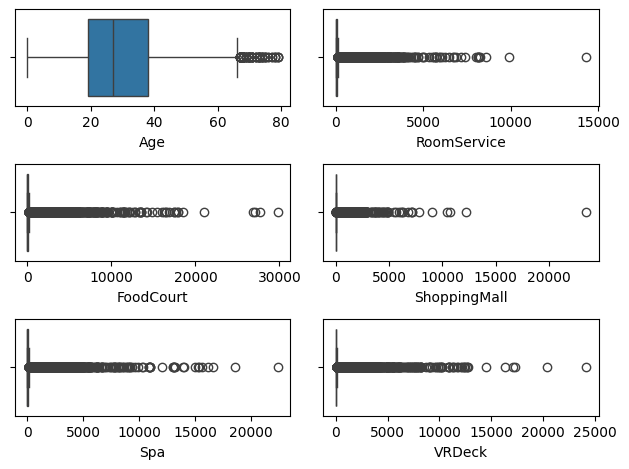

In [11]:
fig, axis = plt.subplots(3, 2)
sns.boxplot(data=df_train, x="Age", ax=axis[0][0])
sns.boxplot(data=df_train, x="RoomService", ax=axis[0][1])
sns.boxplot(data=df_train, x="FoodCourt", ax=axis[1][0])
sns.boxplot(data=df_train, x="ShoppingMall", ax=axis[1][1])
sns.boxplot(data=df_train, x="Spa", ax=axis[2][0])
sns.boxplot(data=df_train, x="VRDeck", ax=axis[2][1])
plt.tight_layout()

Распределение признака `Age` выглядит естественно, а у признаков трат распределение имеет большое количество выбросов справа, создавая тем самым "хвост".

Так как основная доля наблюдение располагается в районе нуля - применять `np.nanpercentile` нельзя, лучше применить `log1p`, чтобы вытянуть хвост и не допустить бесконечности.

Для будущих исследований создадим копию датафрейма.

In [12]:
waste_money_columns = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

for col in waste_money_columns:
    df_train[col] = np.log1p(df_train[col])
    df_test[col] = np.log1p(df_test[col])

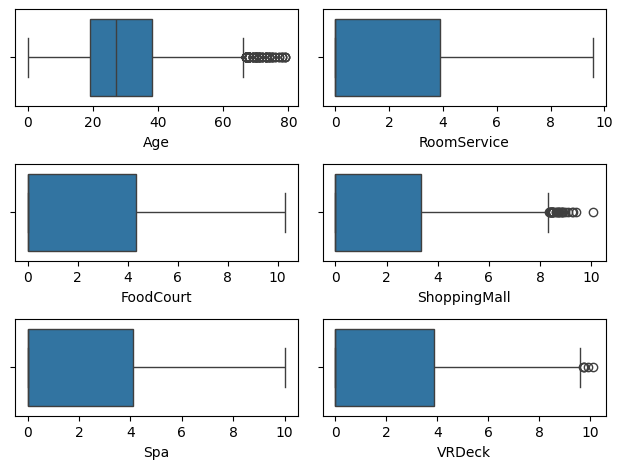

In [13]:
fig, axis = plt.subplots(3, 2)
sns.boxplot(data=df_train, x="Age", ax=axis[0][0])
sns.boxplot(data=df_train, x="RoomService", ax=axis[0][1])
sns.boxplot(data=df_train, x="FoodCourt", ax=axis[1][0])
sns.boxplot(data=df_train, x="ShoppingMall", ax=axis[1][1])
sns.boxplot(data=df_train, x="Spa", ax=axis[2][0])
sns.boxplot(data=df_train, x="VRDeck", ax=axis[2][1])
plt.tight_layout()

In [14]:
df_train.corr(numeric_only=True)["Transported"][:-1]

Age            -0.075026
RoomService    -0.362803
FoodCourt      -0.136035
ShoppingMall   -0.180193
Spa            -0.367705
VRDeck         -0.343462
Name: Transported, dtype: float64

С некоторыми признаками корреляция по целевой переменной уменьшилась в два раза, а с некоторыми поменялся знак.

__Вывод__: чем меньше трат - тем выше шанс быть перенесённым на другую планету.

### Работа с пропусками

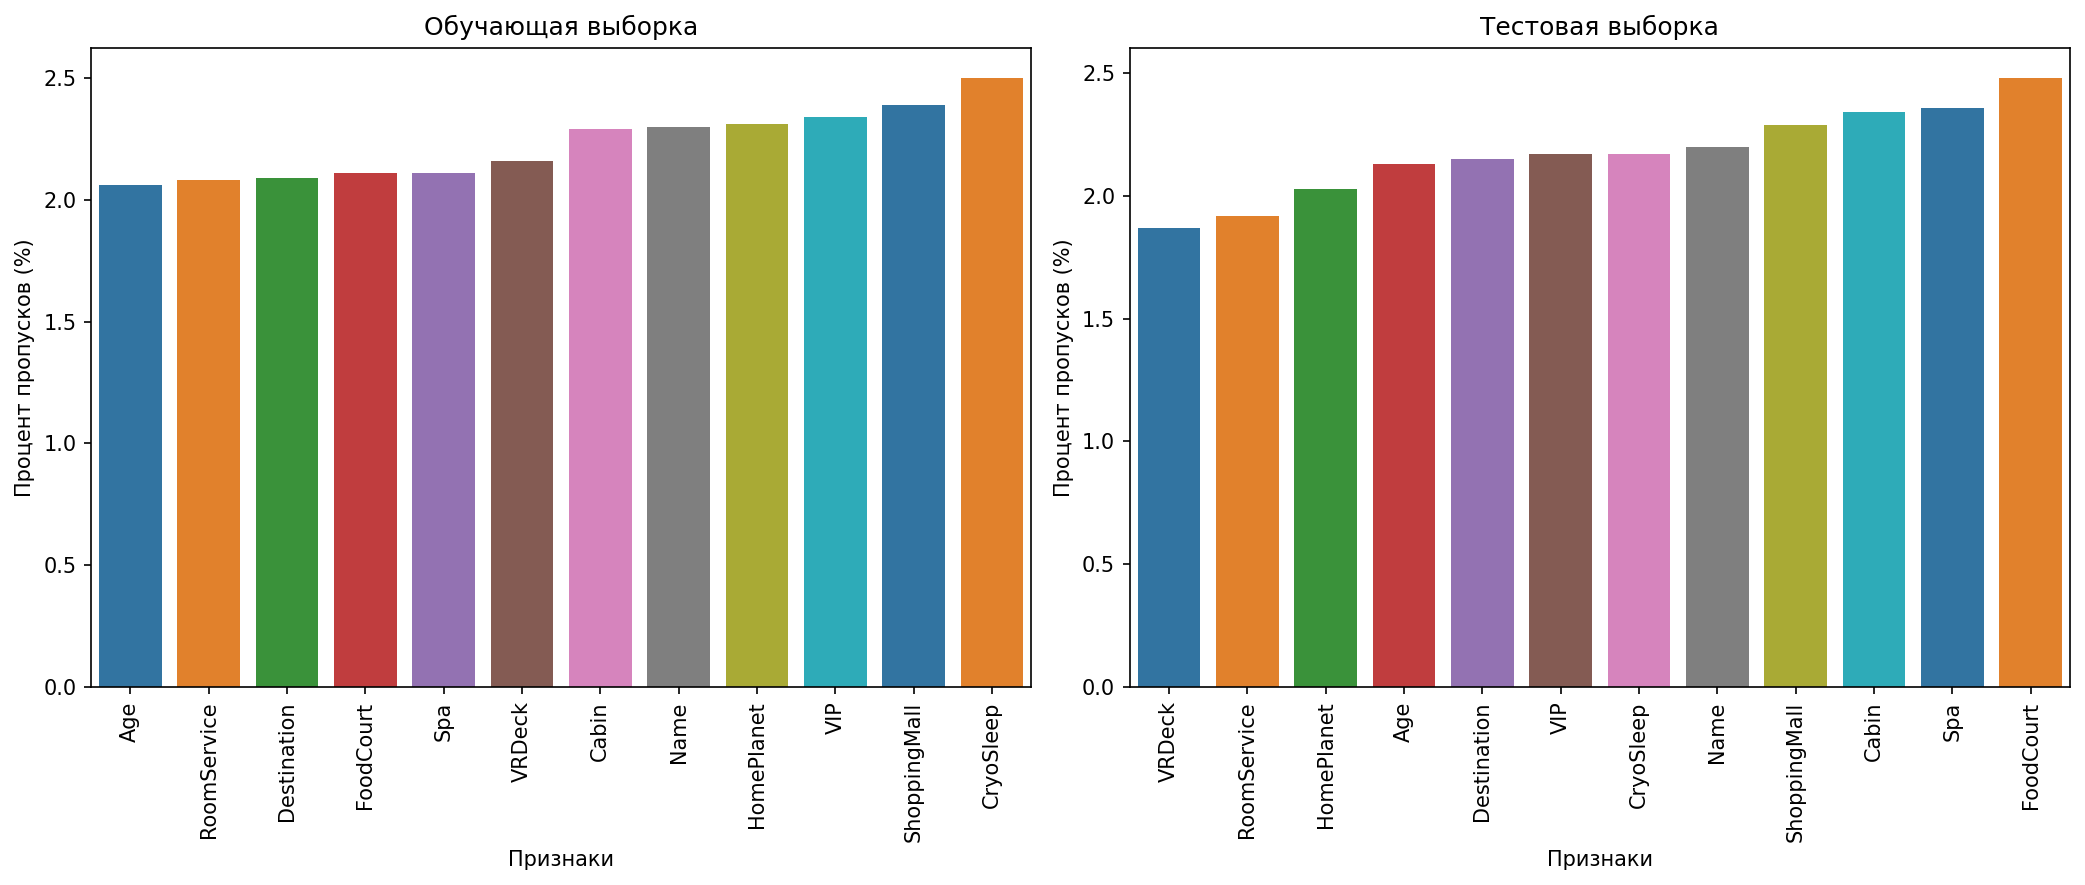

In [15]:
from modules.utils import show_missing_data

show_missing_data(df_train, df_test)

Процент пропущенных значений небольшой, однако в целях сохранения информативности необходимо заполнить пропуски.

#### `Age`

<Axes: xlabel='Age', ylabel='Count'>

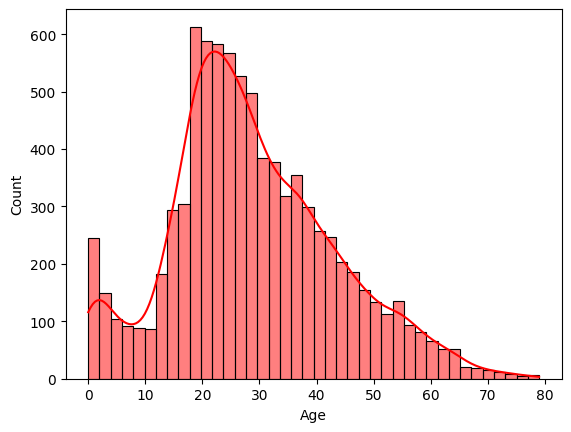

In [16]:
sns.histplot(df_train["Age"], bins=40, kde=True, color="red", edgecolor="black")

"Хвост" уходит вправо из-за редких пожилых пассажиров, поэтому для заполнения пропусков лучше использовать медианное значение. 

In [17]:
df_train["Age"] = df_train["Age"].fillna(df_train["Age"].median())
df_test["Age"] = df_test["Age"].fillna(df_train["Age"].median())

#### `RoomService`

<Axes: xlabel='RoomService', ylabel='Count'>

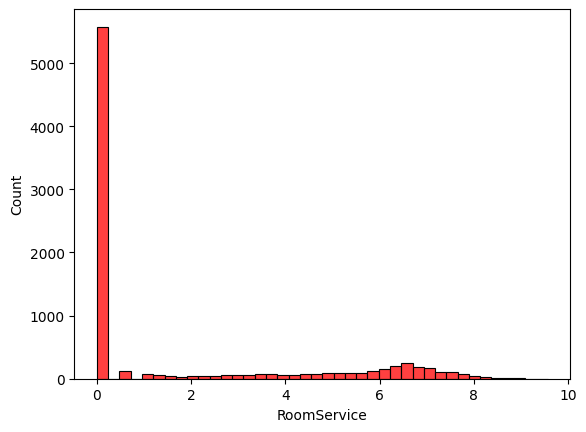

In [18]:
sns.histplot(data=df_train, x="RoomService", bins=40, color="red", edgecolor="black")

Большинство людей не тратили деньги на обслуживание в номере, медианное значение равно нулю. Исходя из логики, можно заполнить пропуски нулём для людей, находящихся в креокамере, а также медианой.

In [19]:
from modules.utils import percent_missing

percent_missing(df_train, "RoomService")

"Процент пропущенных значений в 'RoomService': 2.08%"

In [20]:
for df in [df_train, df_test]:
    df.loc[df["RoomService"].isna() & df["CryoSleep"], "RoomService"] = 0

In [21]:
for df in [df_train, df_test]:
    df.loc[(df["RoomService"].isna()) & (df["CryoSleep"] == False), "RoomService"] = df_train["RoomService"].median()

In [22]:
percent_missing(df_train, "RoomService")

"Процент пропущенных значений в 'RoomService': 0.02%"

In [23]:
percent_missing(df_test, "RoomService")

"Процент пропущенных значений в 'RoomService': 0.02%"

#### `Destination`

In [24]:
print(f"Список мест, куда прибывают пассажиры: {df_train["Destination"].unique()}")

Список мест, куда прибывают пассажиры: ['TRAPPIST-1e' 'PSO J318.5-22' '55 Cancri e' nan]


In [25]:
percent_missing(df_train, "Destination")

"Процент пропущенных значений в 'Destination': 2.09%"

In [26]:
percent_missing(df_test, "Destination")

"Процент пропущенных значений в 'Destination': 2.15%"

In [27]:
Destination_map = df_train.groupby("HomePlanet", dropna=False)["Destination"].apply(lambda x: x.mode()[0]).to_dict()

In [28]:
Destination_map

{'Earth': 'TRAPPIST-1e',
 'Europa': 'TRAPPIST-1e',
 'Mars': 'TRAPPIST-1e',
 nan: 'TRAPPIST-1e'}

Заполнение заполнение самым популярным значением через признак `HomePlanet` не даст нужный результат: мы получаем глобальную моду.
В документации сказано, что первые 4 цифры `PassengerId` - группа, с которой путешествует пассажир.

In [29]:
df_train["Group"] = df_train["PassengerId"].apply(lambda x: x.split("_")[0])
df_test["Group"] = df_test["PassengerId"].apply(lambda x: x.split("_")[0])

group_dest_map = pd.concat([df_train, df_test]).dropna(subset="Destination").groupby("Group")["Destination"].first().to_dict()

for df in [df_train, df_test]:
    df["Destination"] = df["Destination"].fillna(df["Group"].map(group_dest_map))

In [30]:
percent_missing(df_train, "Destination")

"Процент пропущенных значений в 'Destination': 1.18%"

In [31]:
percent_missing(df_test, "Destination")

"Процент пропущенных значений в 'Destination': 1.19%"

Возможно, пассажир с пропуском в `Destination` летел один, либо у всех в группе был `nan`. Заполнение глобальной модой не сильно повлияет на результат.

In [32]:
for df in [df_train, df_test]:
    df["Destination"] = df["Destination"].fillna(df["Destination"].mode()[0])

#### `ShoppingMall`, `RoomService`, `FoodCourt`, `VRDeck`, `Spa`

Данные признаки представляют собой траты пассажиров на различные услуги, предоставляемые на корабле. Логично, что находясь в креосне - пассажир ничего не потратит; также ключевую роль играет возраст - ребёнок не может потратить много, бодрствующие пассажиры тратят деньги в зависимости от своей возрастной категории.

<Axes: xlabel='Age', ylabel='TotalSpend'>

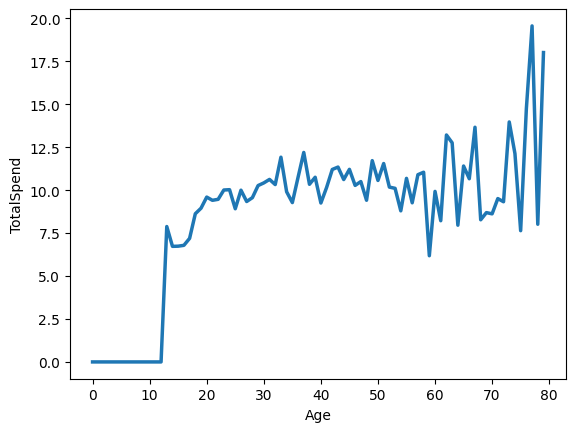

In [33]:
df_train["TotalSpend"] = df_train[waste_money_columns].sum(axis=1)

sns.lineplot(data=df_train, x="Age", y="TotalSpend", estimator="mean", errorbar=None, lw=2.5)

На графике видна зависимость денежных трат от возраста. Пассажиры возрастной группы до 12 лет не тратят деньги.

In [34]:
unfilled_spend_cols = ["ShoppingMall", "RoomService", "FoodCourt", "VRDeck", "Spa"]

print("Процент пропущенных данных в тренировочной выборке")
for col in unfilled_spend_cols:
    print(percent_missing(df_train, col))

Процент пропущенных данных в тренировочной выборке
Процент пропущенных значений в 'ShoppingMall': 2.39%
Процент пропущенных значений в 'RoomService': 0.02%
Процент пропущенных значений в 'FoodCourt': 2.11%
Процент пропущенных значений в 'VRDeck': 2.16%
Процент пропущенных значений в 'Spa': 2.11%


In [35]:
print("Процент пропущенных данных в тестовой выборке")
for col in unfilled_spend_cols:
    print(percent_missing(df_test, col))

Процент пропущенных данных в тестовой выборке
Процент пропущенных значений в 'ShoppingMall': 2.29%
Процент пропущенных значений в 'RoomService': 0.02%
Процент пропущенных значений в 'FoodCourt': 2.48%
Процент пропущенных значений в 'VRDeck': 1.87%
Процент пропущенных значений в 'Spa': 2.36%


In [36]:
bins = [0, 12, 20, 30, 60, 80]
labels = ["Child", "Teen", "Middle", "Adult", "Senior"]

df_train["AgeGroup"] = pd.cut(df_train["Age"], bins=bins, labels=labels, include_lowest=True)
df_test["AgeGroup"] = pd.cut(df_test["Age"], bins=bins, labels=labels, include_lowest=True)

In [37]:
for col in unfilled_spend_cols:
    for df in [df_train, df_test]:
        zero_mask = ((df["CryoSleep"]) | (df["AgeGroup"] == "Child"))
        df.loc[zero_mask & df[col].isna(), col] = 0

    col_map = df_train[df_train["CryoSleep"] == False].groupby("AgeGroup", dropna=False)[col].median().to_dict()

    for df in [df_train, df_test]:
        fill_values = df["AgeGroup"].map(col_map).astype("float64")
        df[col] = df[col].fillna(fill_values)

C:\Users\egoro\AppData\Local\Temp\ipykernel_2096\68304432.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  col_map = df_train[df_train["CryoSleep"] == False].groupby("AgeGroup", dropna=False)[col].median().to_dict()
C:\Users\egoro\AppData\Local\Temp\ipykernel_2096\68304432.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  col_map = df_train[df_train["CryoSleep"] == False].groupby("AgeGroup", dropna=False)[col].median().to_dict()
C:\Users\egoro\AppData\Local\Temp\ipykernel_2096\68304432.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pand

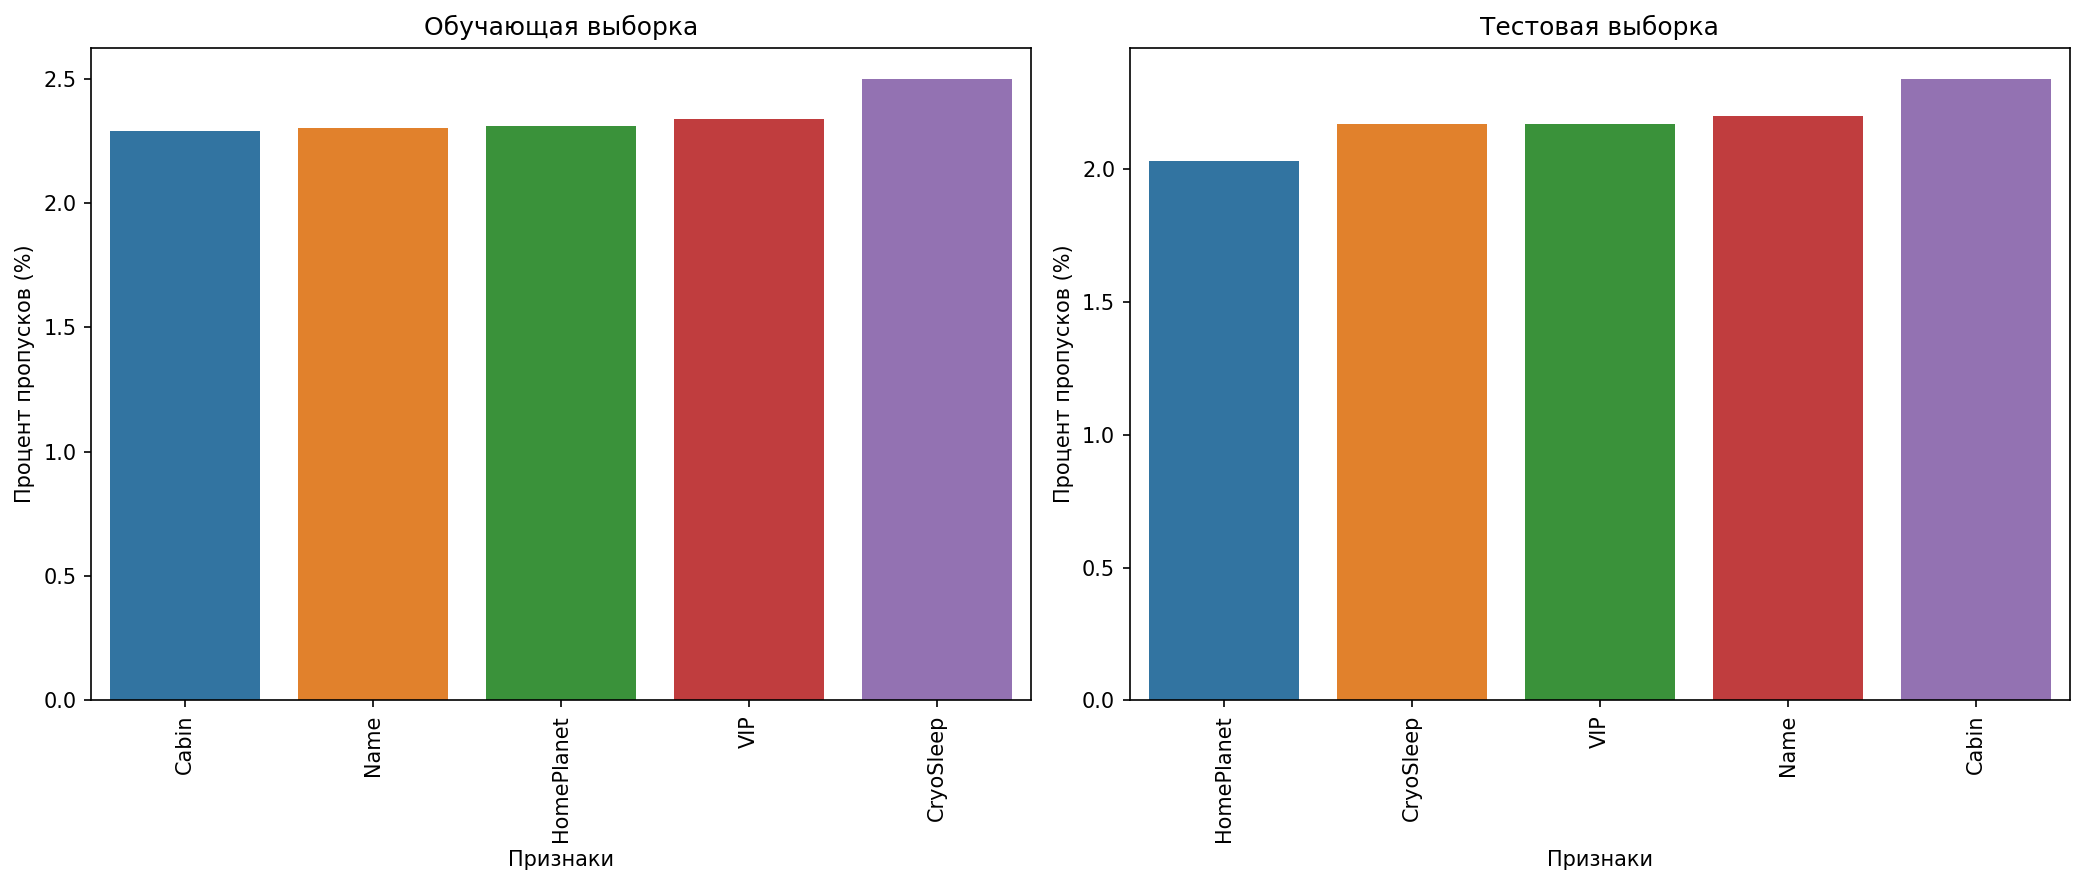

In [38]:
show_missing_data(df_train, df_test)